In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [63]:
import json
from typing import List


def check_insufficient_evidence(json_paths: List[Path], label: str | None = None) -> pd.DataFrame:
    """Scan BioASQ-style generation JSONs for 'Insufficient evidence' consistency.

    For each file, counts questions where evidence_ids is empty and checks whether
    ideal_answer contains the string "Insufficient evidence". Also flags the inverse
    (text says "Insufficient evidence" but evidence_ids is non-empty).
    """
    rows: list[dict] = []
    mismatches: list[tuple[str, str, str]] = []

    for path in json_paths:
        try:
            with path.open("r", encoding="utf-8") as f:
                data = json.load(f)
        except Exception as e:  # pragma: no cover - defensive
            print(f"Failed to read {path}: {e}")
            continue

        questions = data.get("questions", [])
        total = len(questions)
        empty_ev = 0
        bad_missing = 0  # evidence_ids empty but no 'Insufficient evidence' text
        bad_extra = 0    # text says 'Insufficient evidence' but evidence_ids non-empty

        for q in questions:
            evid = q.get("evidence_ids", [])
            ideal = q.get("ideal_answer", "")
            qtype = str(q.get("type", "")).lower()
            is_yesno = qtype in {"yesno", "yes/no", "yes-no"}
            is_empty = isinstance(evid, list) and len(evid) == 0
            has_text = isinstance(ideal, str) and "Insufficient evidence" in ideal

            if is_empty and not is_yesno:
                empty_ev += 1
            if is_empty and not has_text and not is_yesno:
                bad_missing += 1
                mismatches.append((str(path), str(q.get("id", "")), "empty_evidence_no_text"))
            # For yes/no questions we allow 'Insufficient evidence' even when evidence_ids is non-empty
            if has_text and not is_empty and not is_yesno:
                bad_extra += 1
                mismatches.append((str(path), str(q.get("id", "")), "text_but_evidence_present"))

        rows.append(
            {
                "file": str(path),
                "label": label,
                "n_questions": total,
                "n_empty_evidence": empty_ev,
                "n_empty_no_text": bad_missing,
                "n_text_but_evidence": bad_extra,
            }
        )

    df = pd.DataFrame(rows)
    if not df.empty:
        print("Insufficient evidence summary per JSON file:")
        display(df)
    else:
        print("No JSON files found for Insufficient evidence check.")

    if mismatches:
        print("\nPotential mismatches (showing first 20):")
        for p, qid, kind in mismatches[:20]:
            print(f"  {kind}: file={p}, question_id={qid}")
    else:
        print("\nNo mismatches between empty evidence_ids and 'Insufficient evidence' text.")

    return df

# use ground truth compare temperature

In [64]:
# Check 'Insufficient evidence' consistency for ground-truth temperature JSONs

# Ground-truth generation JSONs live under output/using_ground_truth_generation/<temp>/*_golden_answers.json

base = Path("..")
gt_json_root = base / "output/using_ground_truth_generation"
gt_json_paths = sorted(gt_json_root.glob("*/*_golden_answers.json"))

print("Checking ground-truth generation JSONs for Insufficient evidence consistency (temperature variants)...")
_ = check_insufficient_evidence(gt_json_paths, label="groundtruth_temperature")

Checking ground-truth generation JSONs for Insufficient evidence consistency (temperature variants)...
Insufficient evidence summary per JSON file:


,file,label,n_questions,n_empty_evidence,n_empty_no_text,n_text_but_evidence
0,../output/using_ground_truth_generation/0.0/13...,groundtruth_temperature,85,0,0,0
1,../output/using_ground_truth_generation/0.0/13...,groundtruth_temperature,85,0,0,0
2,../output/using_ground_truth_generation/0.0/13...,groundtruth_temperature,85,0,0,0
3,../output/using_ground_truth_generation/0.0/13...,groundtruth_temperature,85,0,0,0
4,../output/using_ground_truth_generation/0.3/13...,groundtruth_temperature,85,0,0,0
5,../output/using_ground_truth_generation/0.3/13...,groundtruth_temperature,85,0,0,0
6,../output/using_ground_truth_generation/0.3/13...,groundtruth_temperature,85,0,0,0
7,../output/using_ground_truth_generation/0.3/13...,groundtruth_temperature,85,0,0,0
8,../output/using_ground_truth_generation/defaul...,groundtruth_temperature,85,0,0,0
9,../output/using_ground_truth_generation/defaul...,groundtruth_temperature,85,0,0,0



No mismatches between empty evidence_ids and 'Insufficient evidence' text.


In [65]:
# Compare generation metrics across ground-truth temperatures

# Base dir is already defined as `base = Path("..")` above
gt_base = base / "report/groundtruth"

conditions = {
    "temp_0.0": gt_base / "0.0/phaseB_report.tsv",
    "temp_0.3": gt_base / "0.3/phaseB_report.tsv",
    "temp_0.8": gt_base / "default/phaseB_report.tsv",
}

metrics = ["YN_Acc", "F_MRR", "L_F1", "R_2_Rec", "R_SU4_Rec"]

# Load all three reports
reports = {
    name: pd.read_csv(path, sep="\t")
    for name, path in conditions.items()
}

# 1) Overall summary (mean over all splits per condition)
summary_rows = []
for name, df in reports.items():
    row = {"condition": name}
    for m in metrics:
        # ensure numeric (in case of string columns)
        row[m] = pd.to_numeric(df[m], errors="coerce").mean()
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("condition")
print("Overall mean metrics per condition (averaged over all splits):")
display(summary_df)

# 2) Detailed table: metrics per split and condition
long_rows = []
for name, df in reports.items():
    tmp = df[["split"] + metrics].copy()
    tmp["condition"] = name
    long_rows.append(tmp)

long_df = pd.concat(long_rows, ignore_index=True)
print("\nPer-split metrics for each condition:")
display(long_df)

Overall mean metrics per condition (averaged over all splits):


,YN_Acc,F_MRR,L_F1,R_2_Rec,R_SU4_Rec
condition,,,,,
temp_0.0,0.940176,0.498806,0.517660,0.325928,0.338202
temp_0.3,0.940176,0.499368,0.518879,0.323829,0.335359
temp_0.8,0.940176,0.498806,0.518268,0.326744,0.338859



Per-split metrics for each condition:


,split,YN_Acc,F_MRR,L_F1,R_2_Rec,R_SU4_Rec,condition
0,13B1_golden_answers,1.000000,0.493590,0.451023,0.326817,0.339897,temp_0.0
1,13B2_golden_answers,0.941176,0.518519,0.507038,0.393883,0.392359,temp_0.0
2,13B3_golden_answers,0.909091,0.450000,0.548267,0.299262,0.313963,temp_0.0
3,13B4_golden_answers,0.923077,0.590909,0.505992,0.257630,0.274323,temp_0.0
4,training14b_10pct_sample_answers,0.927536,0.441011,0.575977,0.352047,0.370466,temp_0.0
5,13B1_golden_answers,1.000000,0.493590,0.453094,0.333356,0.336309,temp_0.3
6,13B2_golden_answers,0.941176,0.518519,0.499961,0.373732,0.376570,temp_0.3
7,13B3_golden_answers,0.909091,0.450000,0.549985,0.293650,0.314302,temp_0.3
8,13B4_golden_answers,0.923077,0.590909,0.520355,0.262075,0.278317,temp_0.3
9,training14b_10pct_sample_answers,0.927536,0.443820,0.571001,0.356331,0.371296,temp_0.3


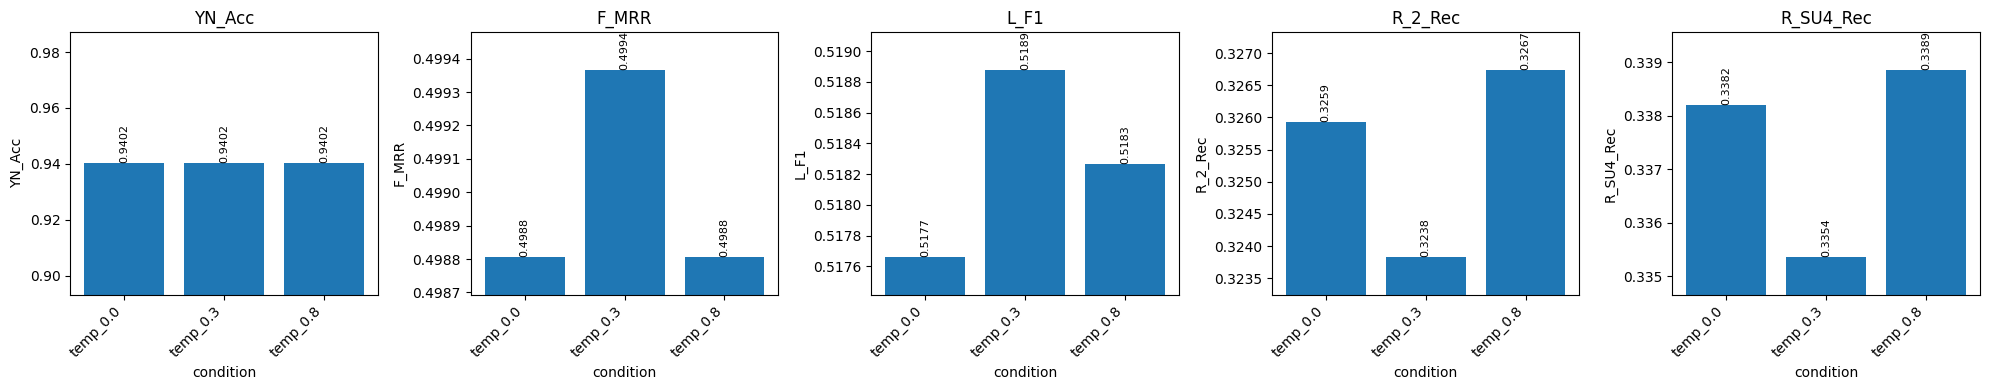

In [66]:
# Plot comparison of metrics across conditions (zoomed to small differences)

# We assume `summary_df` from the previous cell is available
# Rows: conditions, Columns: metrics

fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharey=False)

if len(metrics) == 1:
    axes = [axes]

for ax, m in zip(axes, metrics):
    vals = summary_df[m].values
    x = np.arange(len(summary_df.index))

    # bar for each condition
    ax.bar(x, vals)
    ax.set_title(m)
    ax.set_xlabel("condition")
    ax.set_ylabel(m)
    ax.set_xticks(x)
    ax.set_xticklabels(summary_df.index, rotation=45, ha="right")

    # Zoom y-axis around the data range so small differences are visible
    vmin, vmax = vals.min(), vals.max()
    rng = vmax - vmin
    if rng == 0:
        # all equal: just put a small band around the value
        pad = max(0.001, 0.05 * abs(vmin) if vmin != 0 else 0.01)
        ax.set_ylim(vmin - pad, vmax + pad)
    else:
        # add a bit of padding but keep focus on this narrow band
        pad = 0.2 * rng
        ax.set_ylim(max(0, vmin - pad), min(1.0, vmax + pad))

    # Annotate exact values on top of bars
    for xi, v in zip(x, vals):
        ax.text(xi, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
# Per-split analysis (same logic as above, but done separately for each split)
# plus an extra question-type-split analysis for R_2_Rec.

split_values = sorted(perq_with_retr["split"].dropna().unique().tolist())
print(f"Running per-split analysis for {len(split_values)} splits:")
for s in split_values:
    print(" -", s)

for split_name in split_values:
    df_split_all = perq_with_retr[perq_with_retr["split"] == split_name].copy()

    print(f"\n===== Split: {split_name} =====")

    # --- Association plots (MAP@10 vs generation metrics) ---
    fig, axes = plt.subplots(1, len(gen_cols), figsize=(4 * len(gen_cols), 4), sharex=False, sharey=False)
    if len(gen_cols) == 1:
        axes = [axes]
    fig.suptitle(f"Split: {split_name} (MAP@10 associations)")

    assoc_rows_split = []
    for ax, (g_name, g_col) in zip(axes, gen_cols.items()):
        df_pair = df_split_all[[retr_col, g_col, "question_type"]].dropna().copy()
        df_pair = filter_by_metric_type(df_pair, g_name)

        x = pd.to_numeric(df_pair[retr_col], errors="coerce")
        y = pd.to_numeric(df_pair[g_col], errors="coerce")
        keep = x.notna() & y.notna()
        x = x[keep].values
        y = y[keep].values

        ax.scatter(x, y, alpha=0.3, s=8)
        ax.set_xlabel("MAP@10")
        ax.set_ylabel(g_name)

        row = {
            "split": split_name,
            "retrieval": "MAP@10",
            "generation": g_name,
            "question_type_filter": metric_qtype.get(g_name),
            "n": int(len(x)),
            "method": None,
            "stat": np.nan,
            "p": np.nan,
            "stat_MAP_gt0": np.nan,
            "p_MAP_gt0": np.nan,
        }

        if g_name == "YN_Acc":
            if sm is not None and len(np.unique(y)) >= 2 and len(y) > 2:
                X = sm.add_constant(x)
                try:
                    model = sm.Logit(y, X).fit(disp=False)
                    beta = float(model.params[1])
                    pval = float(model.pvalues[1])
                    title = f"MAP@10 vs {g_name}\nLogit beta={beta:.3f}, p={pval:.1e}"
                    row.update({"method": "logit", "stat": beta, "p": pval})
                except Exception:
                    title = f"MAP@10 vs {g_name}\nLogit failed"
                    row.update({"method": "logit_failed"})
            else:
                title = f"MAP@10 vs {g_name}\nLogit unavailable"
                row.update({"method": "logit_unavailable"})
        elif g_name == "F_MRR":
            if kendalltau is not None and len(x) > 1:
                tau_all, p_all = kendalltau(x, y)
                title = f"MAP@10 vs {g_name}\nKendall tau={tau_all:.3f}, p={p_all:.1e}"
                row.update({"method": "kendall", "stat": float(tau_all), "p": float(p_all)})

                mask_pos = x > 0
                if mask_pos.sum() > 1:
                    tau_pos, p_pos = kendalltau(x[mask_pos], y[mask_pos])
                    row.update({"stat_MAP_gt0": float(tau_pos), "p_MAP_gt0": float(p_pos)})
            else:
                title = f"MAP@10 vs {g_name}\nKendall unavailable"
                row.update({"method": "kendall_unavailable"})
        else:
            if spearmanr is not None and len(x) > 1:
                rho_all, p_all = spearmanr(x, y)
                title = f"MAP@10 vs {g_name}\nSpearman rho={rho_all:.3f}, p={p_all:.1e}"
                row.update({"method": "spearman", "stat": float(rho_all), "p": float(p_all)})

                mask_pos = x > 0
                if mask_pos.sum() > 1:
                    rho_pos, p_pos = spearmanr(x[mask_pos], y[mask_pos])
                    row.update({"stat_MAP_gt0": float(rho_pos), "p_MAP_gt0": float(p_pos)})
            else:
                title = f"MAP@10 vs {g_name}\nSpearman unavailable"
                row.update({"method": "spearman_unavailable"})

        ax.set_title(title, fontsize=9)
        assoc_rows_split.append(row)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

    assoc_split_df = pd.DataFrame(assoc_rows_split)
    print("Association summary (this split):")
    display(assoc_split_df)

    # --- Extra: R_2_Rec split by question type ---
    r2_types = sorted(df_split_all["question_type"].dropna().unique().tolist())
    if r2_types:
        fig, axes = plt.subplots(1, len(r2_types), figsize=(4 * len(r2_types), 4), sharex=False, sharey=False)
        if len(r2_types) == 1:
            axes = [axes]
        fig.suptitle(f"Split: {split_name} (MAP@10 vs R_2_Rec by question type)")

        r2_type_rows = []
        for ax, qtype in zip(axes, r2_types):
            df_t = df_split_all[df_split_all["question_type"] == qtype][[retr_col, "R_2_Rec"]].copy()
            df_t[retr_col] = pd.to_numeric(df_t[retr_col], errors="coerce")
            df_t["R_2_Rec"] = pd.to_numeric(df_t["R_2_Rec"], errors="coerce")
            df_t = df_t.dropna()
            x = df_t[retr_col].values
            y = df_t["R_2_Rec"].values
            ax.scatter(x, y, alpha=0.3, s=8)
            ax.set_xlabel("MAP@10")
            ax.set_ylabel("R_2_Rec")

            stat = p = np.nan
            method = "spearman"
            if spearmanr is not None and len(x) > 1:
                stat, p = spearmanr(x, y)
                ax.set_title(f"{qtype}\nrho={stat:.3f}, p={p:.1e}", fontsize=9)
            else:
                ax.set_title(f"{qtype}\nSpearman unavailable", fontsize=9)
                method = "spearman_unavailable"

            r2_type_rows.append(
                {
                    "split": split_name,
                    "question_type": qtype,
                    "n": int(len(x)),
                    "method": method,
                    "stat": stat,
                    "p": p,
                }
            )

        plt.tight_layout(rect=[0, 0, 1, 0.95])
        plt.show()
        print("R_2_Rec by question-type summary (this split):")
        display(pd.DataFrame(r2_type_rows))

    # --- Success@10 threshold MWU (type-filtered) ---
    if mannwhitneyu is not None:
        mwu_rows_split = []
        for g_name, g_col in gen_cols.items():
            df_pair = df_split_all[["Success@10", g_col, "question_type"]].dropna().copy()
            df_pair = filter_by_metric_type(df_pair, g_name)
            g1 = df_pair[df_pair["Success@10"] == 1.0][g_col].values
            g0 = df_pair[df_pair["Success@10"] == 0.0][g_col].values

            if len(g1) > 0 and len(g0) > 0:
                stat, p = mannwhitneyu(g1, g0, alternative="two-sided")
            else:
                stat, p = np.nan, np.nan

            mwu_rows_split.append(
                {
                    "split": split_name,
                    "generation": g_name,
                    "question_type_filter": metric_qtype.get(g_name),
                    "n_success1": len(g1),
                    "n_success0": len(g0),
                    "mean_success1": np.mean(g1) if len(g1) > 0 else np.nan,
                    "mean_success0": np.mean(g0) if len(g0) > 0 else np.nan,
                    "MWU_stat": stat,
                    "MWU_p": p,
                }
            )

        print("Success@10 threshold test (MWU, this split):")
        display(pd.DataFrame(mwu_rows_split))
    else:
        print("SciPy not available; skipping MWU for this split.")

    # --- MAP bins and violin plots (type-filtered) ---
    fig, axes = plt.subplots(1, len(gen_cols), figsize=(4 * len(gen_cols), 4), sharey=False)
    if len(gen_cols) == 1:
        axes = [axes]
    fig.suptitle(f"Split: {split_name} (generation by MAP@10 bins)")

    for ax, (g_name, g_col) in zip(axes, gen_cols.items()):
        df_metric = df_split_all[[retr_col, g_col, "question_type"]].dropna().copy()
        df_metric = filter_by_metric_type(df_metric, g_name)

        if df_metric.empty:
            ax.set_title(f"{g_name}: no data")
            continue

        df_metric["MAP_bin"] = pd.cut(df_metric[retr_col], bins=bins, labels=labels, include_lowest=True)
        data = [df_metric[df_metric["MAP_bin"] == label][g_col].values for label in labels]
        non_empty = [i for i, d in enumerate(data) if len(d) > 0]
        if not non_empty:
            ax.set_title(f"{g_name}: no binned data")
            continue

        data_plot = [data[i] for i in non_empty]
        labels_plot = [labels[i] for i in non_empty]
        positions = np.arange(len(labels_plot))
        ax.violinplot(data_plot, positions=positions, showmeans=True, showextrema=False)
        ax.set_xticks(positions)
        ax.set_xticklabels(labels_plot, rotation=45, ha="right")
        ax.set_title(f"{g_name} by MAP@10 bin")
        ax.set_ylabel(g_name)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

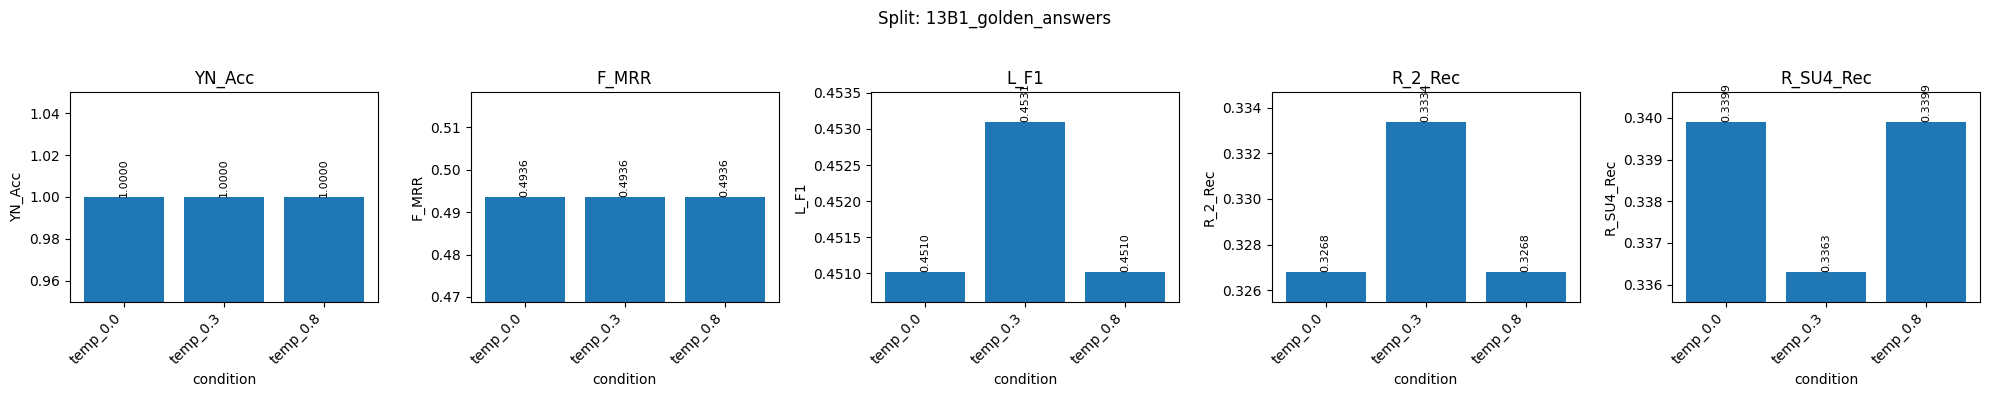

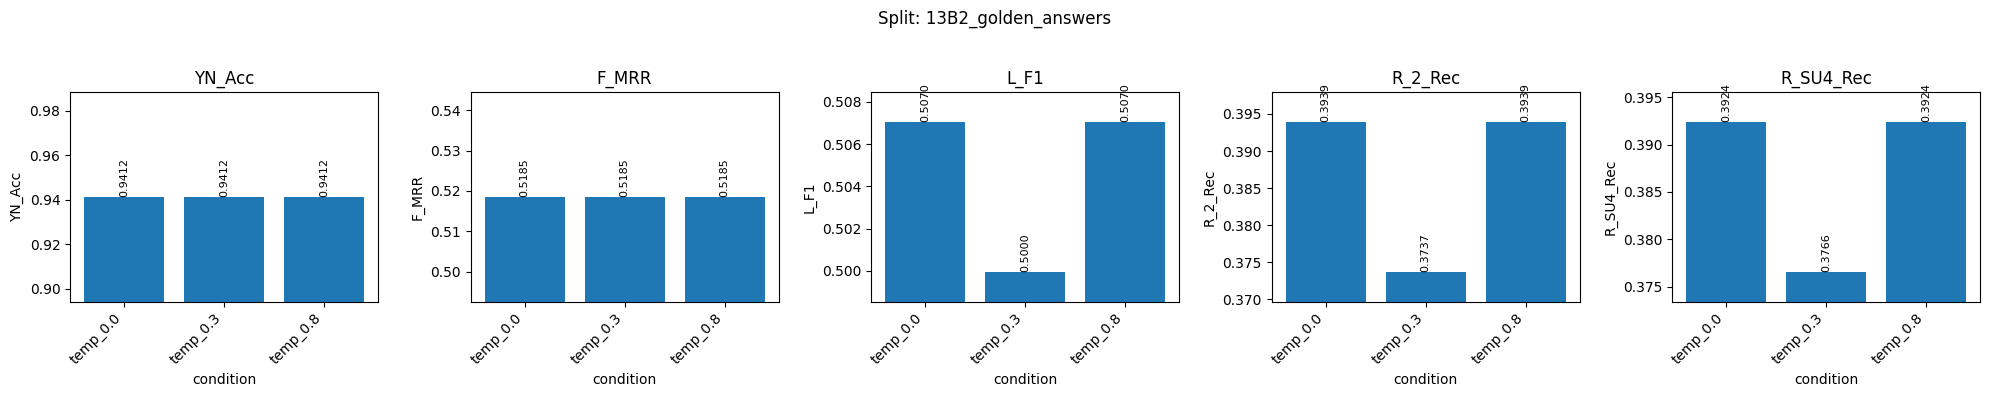

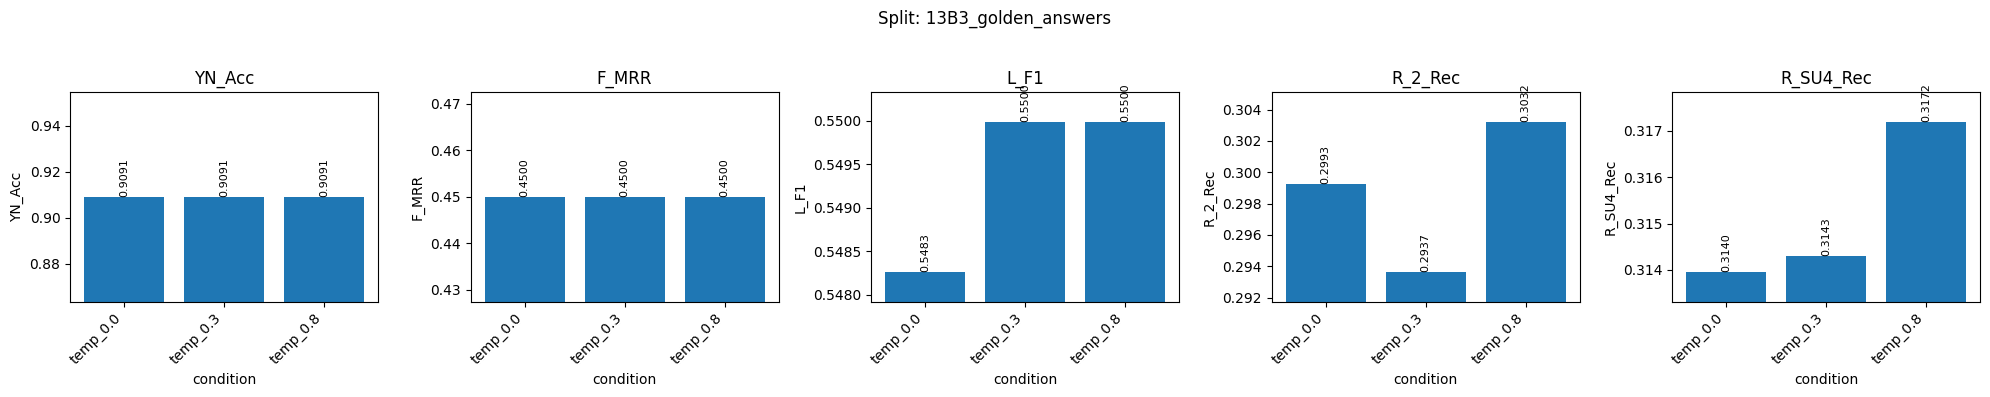

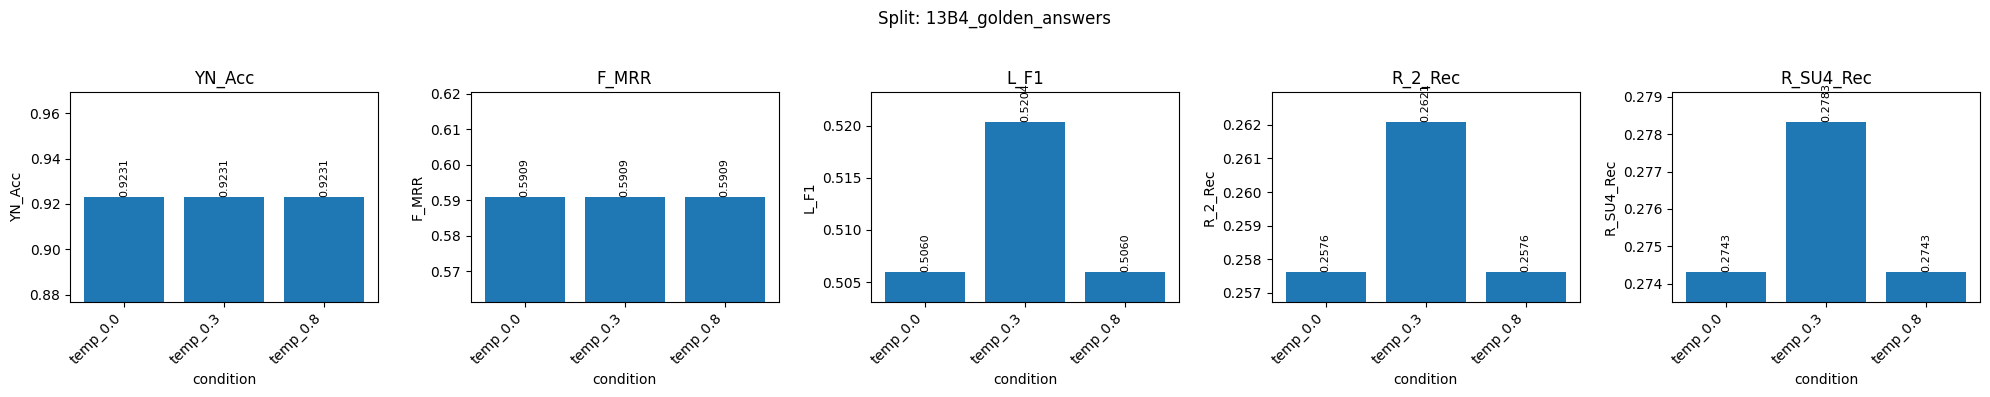

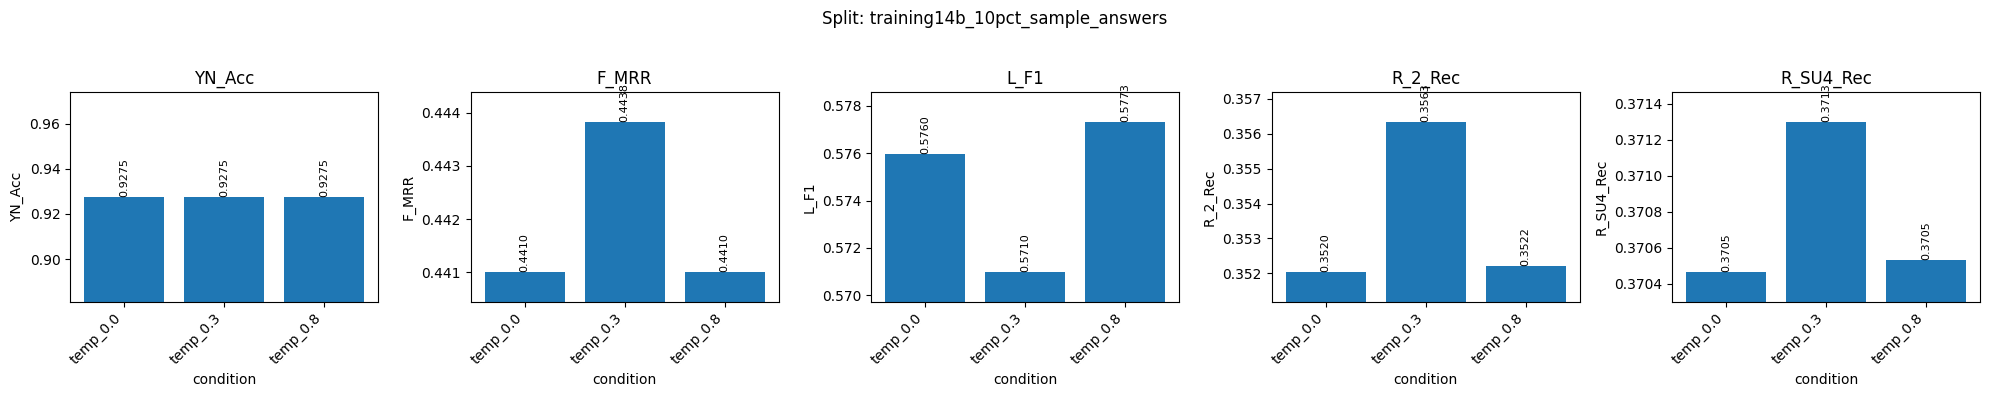

In [67]:
# Plot per-split comparison: for each split, metrics across conditions (zoomed)

# We assume `long_df` from the previous cell is available
# Columns: split, condition, metrics

splits = long_df["split"].unique()

for split in splits:
    df_s = long_df[long_df["split"] == split].set_index("condition")

    fig, axes = plt.subplots(1, len(metrics), figsize=(4 * len(metrics), 4), sharey=False)
    if len(metrics) == 1:
        axes = [axes]

    fig.suptitle(f"Split: {split}")

    for ax, m in zip(axes, metrics):
        vals = df_s[m].values
        conds = df_s.index.tolist()
        x = np.arange(len(conds))

        ax.bar(x, vals)
        ax.set_title(m)
        ax.set_xlabel("condition")
        ax.set_ylabel(m)
        ax.set_xticks(x)
        ax.set_xticklabels(conds, rotation=45, ha="right")

        # Zoom y-axis around the data range so small differences are visible
        vmin, vmax = vals.min(), vals.max()
        rng = vmax - vmin
        if rng == 0:
            pad = max(0.001, 0.05 * abs(vmin) if vmin != 0 else 0.01)
            ax.set_ylim(vmin - pad, vmax + pad)
        else:
            pad = 0.2 * rng
            ax.set_ylim(max(0, vmin - pad), min(1.0, vmax + pad))

        # Annotate exact values on top of bars
        for xi, v in zip(x, vals):
            ax.text(xi, v, f"{v:.4f}", ha="center", va="bottom", fontsize=8, rotation=90)

    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

# correlation between retrieval and generation results

In [53]:
# Check 'Insufficient evidence' consistency for workflow_local_10pct_hpc_bge generation JSONs

wf_json_root = base / "output/workflow_local_10pct_hpc_bge/generation"
wf_json_paths = sorted(wf_json_root.glob("*_answers.json"))

print("Checking workflow_local_10pct_hpc_bge generation JSONs for Insufficient evidence consistency...")
_ = check_insufficient_evidence(wf_json_paths, label="workflow_generation")

Checking workflow_local_10pct_hpc_bge generation JSONs for Insufficient evidence consistency...
Insufficient evidence summary per JSON file:


,file,label,n_questions,n_empty_evidence,n_empty_no_text,n_text_but_evidence
0,../output/workflow_local_10pct_hpc_bge/generat...,workflow_generation,85,0,0,0
1,../output/workflow_local_10pct_hpc_bge/generat...,workflow_generation,85,0,0,0
2,../output/workflow_local_10pct_hpc_bge/generat...,workflow_generation,85,0,0,0
3,../output/workflow_local_10pct_hpc_bge/generat...,workflow_generation,85,1,0,0
4,../output/workflow_local_10pct_hpc_bge/generat...,workflow_generation,583,2,1,0



Potential mismatches (showing first 20):
  empty_evidence_no_text: file=../output/workflow_local_10pct_hpc_bge/generation/training14b_10pct_sample_answers.json, question_id=602c1c701cb411341a00011d


Collected 273 factoid questions across 5 files.
Min list length: 1, max: 5


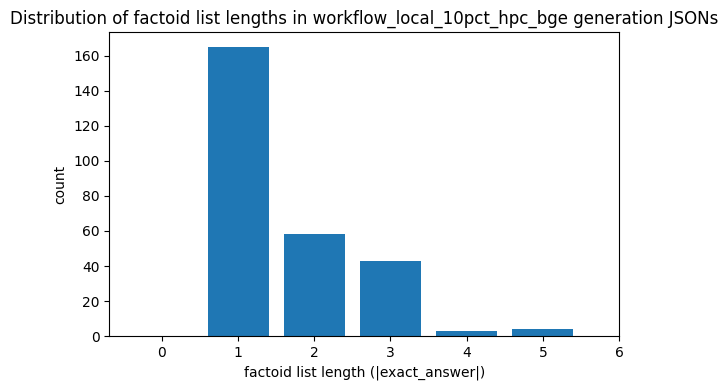

In [73]:
# Histogram of factoid list lengths in workflow_local_10pct_hpc_bge generation JSONs

wf_json_root = base / "output/workflow_local_10pct_hpc_bge/generation"
wf_json_paths = sorted(wf_json_root.glob("*_answers.json"))

factoid_lengths: list[int] = []

for path in wf_json_paths:
    try:
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception as e:  # defensive
        print(f"Failed to read {path}: {e}")
        continue

    for q in data.get("questions", []):
        if str(q.get("type", "")).lower() != "factoid":
            continue
        exact = q.get("exact_answer", [])
        length = 0
        if isinstance(exact, list):
            # BioASQ-style: list of lists of atomic answers / synonyms
            if exact and exact and isinstance(exact[0], list):
                # Total number of atomic answers across all synonym groups
                length = sum(len(inner) for inner in exact if isinstance(inner, list))
            else:
                length = len(exact)
        factoid_lengths.append(length)

if factoid_lengths:
    factoid_lengths = [int(x) for x in factoid_lengths]
    max_len = max(factoid_lengths)
    print(f"Collected {len(factoid_lengths)} factoid questions across {len(wf_json_paths)} files.")
    print(f"Min list length: {min(factoid_lengths)}, max: {max_len}")

    bins = range(0, max_len + 2)
    plt.figure(figsize=(6, 4))
    plt.hist(factoid_lengths, bins=bins, align="left", rwidth=0.8)
    plt.xlabel("factoid list length (|exact_answer|)")
    plt.ylabel("count")
    plt.title("Distribution of factoid list lengths in workflow_local_10pct_hpc_bge generation JSONs")
    plt.xticks(bins)
    plt.tight_layout()
    plt.show()
else:
    print("No factoid questions found in workflow_local_10pct_hpc_bge generation JSONs.")

In [54]:
# Paths (run from notebooks/)
base = Path("..")

phaseA_perq_path = base / "report/phaseA_report_perq.tsv"  # retrieval
phaseB_perq_path = base / "report/phaseB_report_perq.tsv"  # generation

phaseA_perq = pd.read_csv(phaseA_perq_path, sep="\t")
phaseB_perq = pd.read_csv(phaseB_perq_path, sep="\t")

# Align on split + question_id
perq_merged = phaseA_perq.merge(
    phaseB_perq,
    on=["split", "question_id"],
    how="inner",
    suffixes=("_retr", "_gen"),
)

In [59]:
# Select retrieval d_MAP and generation recall metrics
retr_col = "d_MAP"
r2_col = "R_2_Rec"
su4_col = "R_SU4_Rec"

# Clean and drop rows with missing values in the used columns
valid = (
    perq_merged[[retr_col, r2_col, su4_col]]
    .replace({"NA": np.nan})
    .astype(float)
    .dropna()
)

print(f"Valid rows for correlation: {len(valid)}")

corr_r2 = valid[[retr_col, r2_col]].corr(method="spearman").iloc[0, 1]
corr_su4 = valid[[retr_col, su4_col]].corr(method="spearman").iloc[0, 1]

print("spearman corr(d_MAP, R_2_Rec):  ", corr_r2)
print("spearman corr(d_MAP, R_SU4_Rec):", corr_su4)

valid[[retr_col, r2_col, su4_col]].describe()

Valid rows for correlation: 699
spearman corr(d_MAP, R_2_Rec):   0.23828303602367115
spearman corr(d_MAP, R_SU4_Rec): 0.20805302856277652


,d_MAP,R_2_Rec,R_SU4_Rec
count,699.000000,699.000000,699.000000
mean,0.338134,0.242592,0.268912
std,0.335411,0.237795,0.224677
min,0.000000,0.000000,0.000000
25%,0.050000,0.067647,0.107246
50%,0.234444,0.166667,0.200000
75%,0.514722,0.346327,0.364358
max,1.000000,1.000000,1.000000


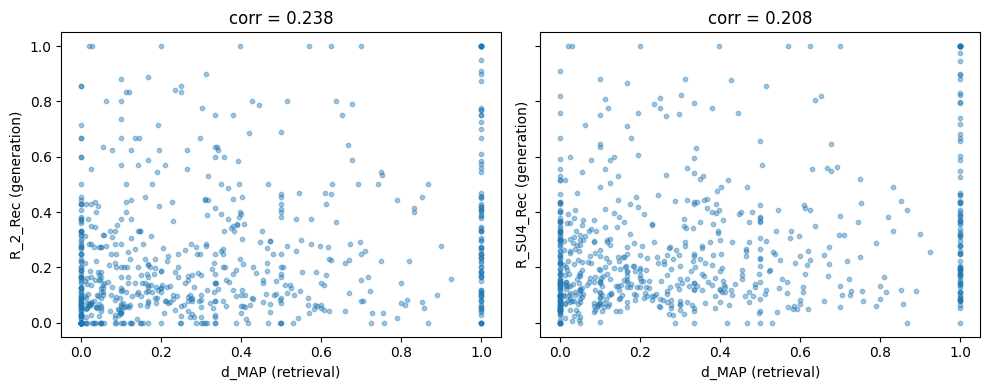

In [60]:
# Quick scatter plots: retrieval d_MAP vs generation recall

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].scatter(valid[retr_col], valid[r2_col], alpha=0.4, s=10)
axes[0].set_xlabel("d_MAP (retrieval)")
axes[0].set_ylabel("R_2_Rec (generation)")
axes[0].set_title(f"corr = {corr_r2:.3f}")

axes[1].scatter(valid[retr_col], valid[su4_col], alpha=0.4, s=10)
axes[1].set_xlabel("d_MAP (retrieval)")
axes[1].set_ylabel("R_SU4_Rec (generation)")
axes[1].set_title(f"corr = {corr_su4:.3f}")

plt.tight_layout()
plt.show()

Deprecated: older consolidated analysis block removed.
Use the v2 consolidated analysis block below.

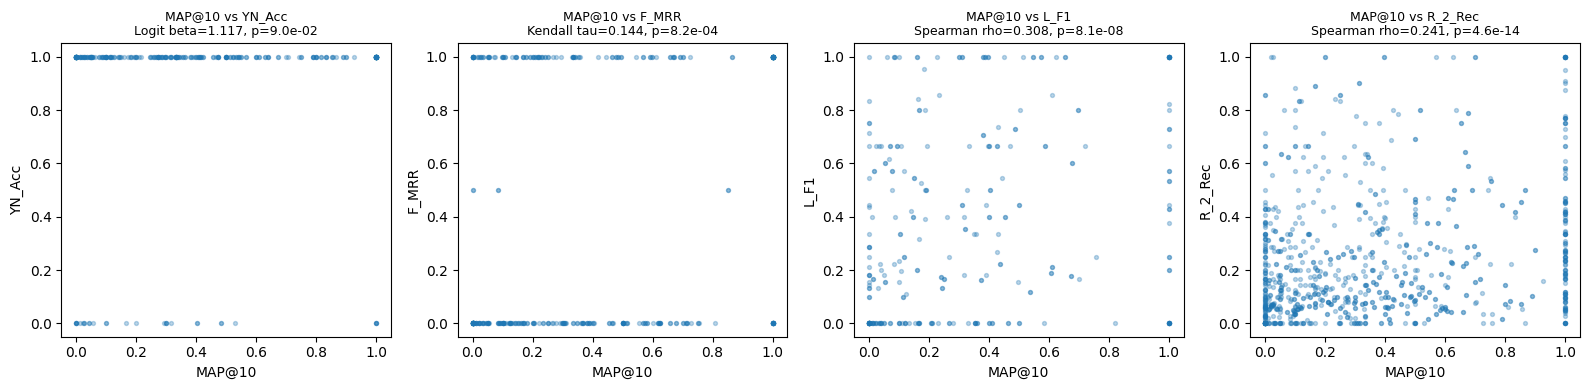

Association summary (MAP@10 panel; logistic for YN_Acc, Kendall for F_MRR, Spearman otherwise):


,retrieval,generation,question_type_filter,n,method,stat,p,stat_MAP_gt0,p_MAP_gt0
0,MAP@10,YN_Acc,yesno,302,logit,1.116964,9.009153e-02,NaN,NaN
1,MAP@10,F_MRR,factoid,368,kendall,0.144421,8.225881e-04,0.135379,3.434141e-03
2,MAP@10,L_F1,list,292,spearman,0.307655,8.078887e-08,0.247786,8.283114e-05
3,MAP@10,R_2_Rec,NaN,956,spearman,0.240653,4.621574e-14,0.225430,5.047403e-11



Success@10 threshold test (Mann-Whitney U, per query, type-filtered):


,generation,question_type_filter,n_success1,n_success0,mean_success1,mean_success0,MWU_stat,MWU_p
0,YN_Acc,yesno,269,33,0.907063,0.848485,4698.5,0.290070
1,F_MRR,factoid,316,52,0.436709,0.288462,9436.0,0.046276
2,L_F1,list,243,49,0.402957,0.255077,7397.0,0.006573
3,R_2_Rec,NaN,822,134,0.246320,0.192807,64514.0,0.001439


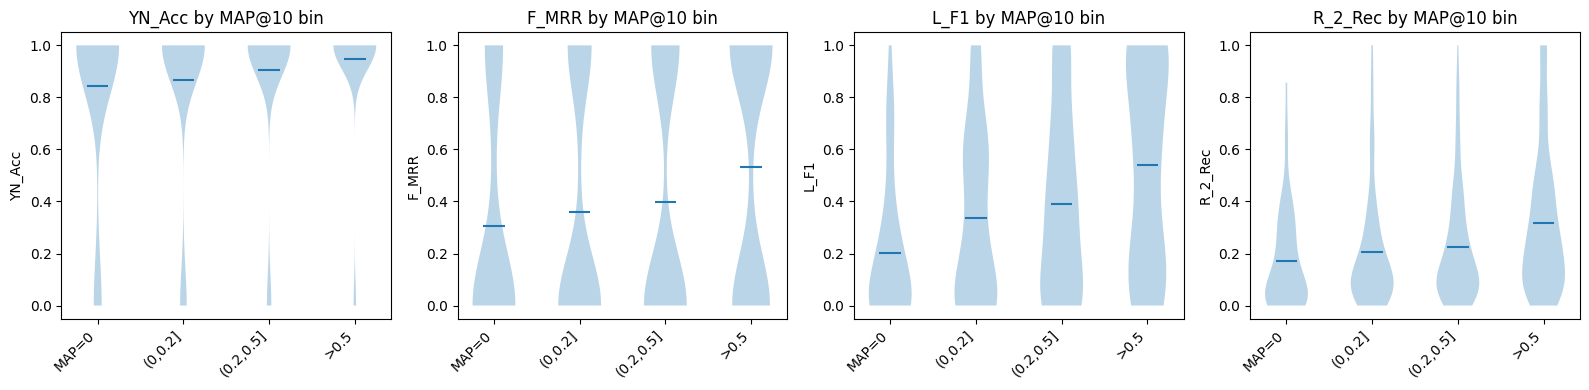

In [81]:
# Consolidated retrieval-generation analysis (v2)
# - MAP@10 axis uses d_MAP/retr_col from phaseA per-query
# - Success@10 is evaluated with MWU only (no Spearman/Logit panel)
# - Question-type aware metrics:
#     YN_Acc -> yesno, F_MRR -> factoid, L_F1 -> list, R_2_Rec -> all
# - For MAP@10 vs F_MRR use Kendall tau; otherwise Spearman (except YN_Acc logistic)

try:
    from scipy.stats import spearmanr, kendalltau, mannwhitneyu
except ImportError:
    spearmanr = None
    kendalltau = None
    mannwhitneyu = None

try:
    import statsmodels.api as sm
except ImportError:
    sm = None

# Retrieval Success@10 from rerank_hybrid per-query CSVs
retrieval_perq_dir = base / "output/workflow_local_10pct_hpc_bge/rerank_hybrid/per_query"
retrieval_perq_frames = []
for csv_path in sorted(retrieval_perq_dir.glob("*.csv")):
    df_r = pd.read_csv(csv_path)
    retrieval_perq_frames.append(df_r[["qid", "Success@10"]])
retrieval_perq = pd.concat(retrieval_perq_frames, ignore_index=True)

# Merge with phaseA+phaseB per-query merged table
perq_with_retr = perq_merged.merge(
    retrieval_perq,
    left_on="question_id",
    right_on="qid",
    how="inner",
)

# Infer question type from workflow generation JSONs
wf_json_root = base / "output/workflow_local_10pct_hpc_bge/generation"
wf_json_paths = sorted(wf_json_root.glob("*_answers.json"))

qtype_rows = []
for path in wf_json_paths:
    try:
        with path.open("r", encoding="utf-8") as f:
            data = json.load(f)
    except Exception:
        continue
    for q in data.get("questions", []):
        qtype_rows.append(
            {
                "question_id": str(q.get("id", "")),
                "question_type": str(q.get("type", "")).lower(),
            }
        )

qtype_df = pd.DataFrame(qtype_rows).drop_duplicates(subset=["question_id"])
perq_with_retr = perq_with_retr.merge(qtype_df, on="question_id", how="left")

retrieval_cols_assoc = {
    "MAP@10": retr_col,  # d_MAP / d_MAP_retr from phaseA per-query
}

gen_cols = {
    "YN_Acc": "YN_Acc",
    "F_MRR": "F_MRR",
    "L_F1": "L_F1",
    "R_2_Rec": "R_2_Rec",
}

metric_qtype = {
    "YN_Acc": "yesno",
    "F_MRR": "factoid",
    "L_F1": "list",
    "R_2_Rec": None,
}

# Numeric cleanup
for col in [retr_col, "Success@10"] + list(gen_cols.values()):
    perq_with_retr[col] = pd.to_numeric(perq_with_retr[col], errors="coerce")

def filter_by_metric_type(df: pd.DataFrame, metric_name: str) -> pd.DataFrame:
    req = metric_qtype.get(metric_name)
    if req is None:
        return df
    return df[df["question_type"] == req]

# 1x4 association plots for MAP@10 vs generation metrics
fig, axes = plt.subplots(1, len(gen_cols), figsize=(4 * len(gen_cols), 4), sharex=False, sharey=False)
if len(gen_cols) == 1:
    axes = [axes]

assoc_rows = []
r_name, r_col = next(iter(retrieval_cols_assoc.items()))

for ax, (g_name, g_col) in zip(axes, gen_cols.items()):
    df_pair = perq_with_retr[[r_col, g_col, "question_type"]].dropna().copy()
    df_pair = filter_by_metric_type(df_pair, g_name)

    x = pd.to_numeric(df_pair[r_col], errors="coerce")
    y = pd.to_numeric(df_pair[g_col], errors="coerce")
    keep = x.notna() & y.notna()
    x = x[keep].values
    y = y[keep].values

    ax.scatter(x, y, alpha=0.3, s=8)
    ax.set_xlabel(r_name)
    ax.set_ylabel(g_name)

    row = {
        "retrieval": r_name,
        "generation": g_name,
        "question_type_filter": metric_qtype.get(g_name),
        "n": int(len(x)),
        "method": None,
        "stat": np.nan,
        "p": np.nan,
        "stat_MAP_gt0": np.nan,
        "p_MAP_gt0": np.nan,
    }

    if g_name == "YN_Acc":
        # Binary outcome: logistic regression
        if sm is not None and len(np.unique(y)) >= 2 and len(y) > 2:
            X = sm.add_constant(x)
            try:
                model = sm.Logit(y, X).fit(disp=False)
                beta = float(model.params[1])
                pval = float(model.pvalues[1])
                title = f"{r_name} vs {g_name}\nLogit beta={beta:.3f}, p={pval:.1e}"
                row.update({"method": "logit", "stat": beta, "p": pval})
            except Exception:
                title = f"{r_name} vs {g_name}\nLogit failed"
                row.update({"method": "logit_failed"})
        else:
            title = f"{r_name} vs {g_name}\nLogit unavailable"
            row.update({"method": "logit_unavailable"})

    elif g_name == "F_MRR":
        # Requested: Kendall for MAP@10 vs F_MRR
        if kendalltau is not None and len(x) > 1:
            tau_all, p_all = kendalltau(x, y)
            title = f"{r_name} vs {g_name}\nKendall tau={tau_all:.3f}, p={p_all:.1e}"
            row.update({"method": "kendall", "stat": float(tau_all), "p": float(p_all)})

            mask_pos = x > 0
            if mask_pos.sum() > 1:
                tau_pos, p_pos = kendalltau(x[mask_pos], y[mask_pos])
                row.update({"stat_MAP_gt0": float(tau_pos), "p_MAP_gt0": float(p_pos)})
        else:
            title = f"{r_name} vs {g_name}\nKendall unavailable"
            row.update({"method": "kendall_unavailable"})

    else:
        # Continuous outcomes: Spearman
        if spearmanr is not None and len(x) > 1:
            rho_all, p_all = spearmanr(x, y)
            title = f"{r_name} vs {g_name}\nSpearman rho={rho_all:.3f}, p={p_all:.1e}"
            row.update({"method": "spearman", "stat": float(rho_all), "p": float(p_all)})

            mask_pos = x > 0
            if mask_pos.sum() > 1:
                rho_pos, p_pos = spearmanr(x[mask_pos], y[mask_pos])
                row.update({"stat_MAP_gt0": float(rho_pos), "p_MAP_gt0": float(p_pos)})
        else:
            title = f"{r_name} vs {g_name}\nSpearman unavailable"
            row.update({"method": "spearman_unavailable"})

    ax.set_title(title, fontsize=9)
    assoc_rows.append(row)

plt.tight_layout()
plt.show()

assoc_summary = pd.DataFrame(assoc_rows)
print("Association summary (MAP@10 panel; logistic for YN_Acc, Kendall for F_MRR, Spearman otherwise):")
display(assoc_summary)

# Success@10 threshold test only (Mann-Whitney U), question-type aware
if mannwhitneyu is not None:
    mwu_rows = []
    for g_name, g_col in gen_cols.items():
        df_pair = perq_with_retr[["Success@10", g_col, "question_type"]].dropna().copy()
        df_pair = filter_by_metric_type(df_pair, g_name)

        g1 = df_pair[df_pair["Success@10"] == 1.0][g_col].values
        g0 = df_pair[df_pair["Success@10"] == 0.0][g_col].values

        if len(g1) > 0 and len(g0) > 0:
            stat, p = mannwhitneyu(g1, g0, alternative="two-sided")
        else:
            stat, p = np.nan, np.nan

        mwu_rows.append(
            {
                "generation": g_name,
                "question_type_filter": metric_qtype.get(g_name),
                "n_success1": len(g1),
                "n_success0": len(g0),
                "mean_success1": np.mean(g1) if len(g1) > 0 else np.nan,
                "mean_success0": np.mean(g0) if len(g0) > 0 else np.nan,
                "MWU_stat": stat,
                "MWU_p": p,
            }
        )

    mwu_df = pd.DataFrame(mwu_rows)
    print("\nSuccess@10 threshold test (Mann-Whitney U, per query, type-filtered):")
    display(mwu_df)
else:
    print("\nSciPy not available; skipping Mann-Whitney U tests for Success@10.")

# MAP@10 bins and violin plots, question-type aware
map_col = retr_col
bins = [-1e-9, 0.0, 0.2, 0.5, 1.0]
labels = ["MAP=0", "(0,0.2]", "(0.2,0.5]", ">0.5"]

fig, axes = plt.subplots(1, len(gen_cols), figsize=(4 * len(gen_cols), 4), sharey=False)
if len(gen_cols) == 1:
    axes = [axes]

for ax, (g_name, g_col) in zip(axes, gen_cols.items()):
    df_metric = perq_with_retr[[map_col, g_col, "question_type"]].dropna().copy()
    df_metric = filter_by_metric_type(df_metric, g_name)

    if df_metric.empty:
        ax.set_title(f"{g_name}: no data")
        continue

    df_metric["MAP_bin"] = pd.cut(df_metric[map_col], bins=bins, labels=labels, include_lowest=True)
    data = [df_metric[df_metric["MAP_bin"] == label][g_col].values for label in labels]

    non_empty = [i for i, d in enumerate(data) if len(d) > 0]
    if not non_empty:
        ax.set_title(f"{g_name}: no binned data")
        continue

    data_plot = [data[i] for i in non_empty]
    labels_plot = [labels[i] for i in non_empty]
    positions = np.arange(len(labels_plot))

    ax.violinplot(data_plot, positions=positions, showmeans=True, showextrema=False)
    ax.set_xticks(positions)
    ax.set_xticklabels(labels_plot, rotation=45, ha="right")
    ax.set_title(f"{g_name} by MAP@10 bin")
    ax.set_ylabel(g_name)

plt.tight_layout()
plt.show()